# Homework 8: Predicting Power Loads with LSTM Networks

## Due: Midnight on **Sunday, March 22nd** (with a 2-hour grace period)  
**Worth:** 85 points

In this assignment, you’ll build and analyze recurrent neural-network models to forecast hourly power demand, using the direct method, and comparing it with autoregressive methods.

**Direct (Non-Autoregressive) Time Series Prediction:**

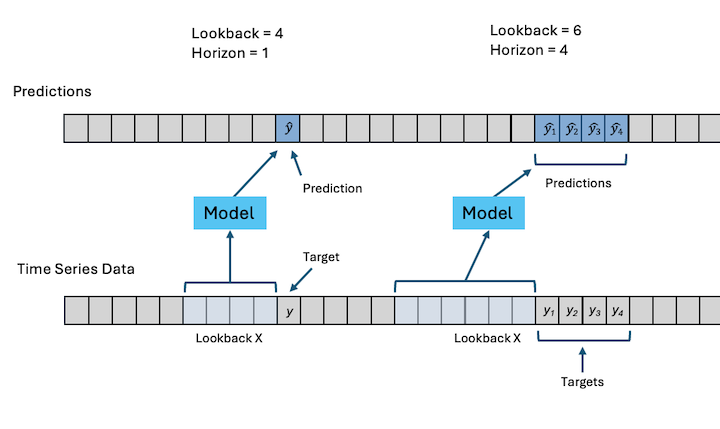


**What we'll do in this homework**

Starting from a working LSTM baseline, you’ll experiment with how the **direct** forcasting models performs, and investigate how **lookback**, **forecast horizon**, and **architecture** affect predictive accuracy and generalization.  
You’ll also explore an **autoregressive** variant, where the model rolls forward one hour at a time—an approach that often highlights how small errors can accumulate.

You’ll complete three problems:

* **Problem 1 — Exploring Lookback and Horizon:**  
  Adjust how far back the model looks and how far ahead it predicts, and examine how these design choices influence MAE/RMSE.

* **Problem 2 — Architectural Tweaks:**  
  Modify the LSTM architecture by deepening the network, stacking layers, or adding a bidirectional layer, and evaluate the effect on validation performance.

* **Problem 3 — Autoregressive Forecasting (ChatGPT Discussion):**  
  Work interactively with ChatGPT to design a one-step-at-a-time autoregressive version of your model, and discuss how it compares to your direct multi-output model.



For each problem, you'll report your best validation metrics, display the learning-curve plots, and briefly reflect on what you learned from the experiment.

There are 5 graded problems, worth 17 points each. 

## Setup and Data Loading


In [1]:
# ---------- Standard Library ----------
import os
import time
import math
import random
from pathlib import Path
from collections import Counter

# Environment (set BEFORE importing TensorFlow)
os.environ["PYTHONHASHSEED"] = "0"        # Disable hash randomization
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Deterministic TF ops where possible
os.environ["TF_CUDNN_DETERMINISM"] = "1"  # Deterministic CuDNN (if GPU)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress TF INFO/WARNING logs

# ---------- Third-Party (General) ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, ShuffleSplit
import kagglehub

# ---------- TensorFlow / Keras ----------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers, initializers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.layers import GlobalMaxPooling1D, SpatialDropout1D, Bidirectional
# Layers (vision)
from tensorflow.keras.layers import (
    Input, Conv2D,Conv1D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalMaxPooling2D, BatchNormalization, ReLU, Flatten, Dense, Dropout
)

# Preprocessing (vision)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ---------- (Optional) NLP-related imports ----------
# If not doing NLP, you can safely remove this block.
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, LSTM, GRU, SpatialDropout1D, Bidirectional, Lambda
)
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.datasets import imdb  # uncomment only if needed

# ---------- Reproducibility ----------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)  # covers TF, Python, and NumPy RNGs

# ---------- Convenience ----------
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

def format_hms(seconds: float) -> str:
    """Format seconds as H:MM:SS."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example:
# start = time.time()
# ... your code ...
# print("Elapsed:", format_hms(time.time() - start))


/home/tbran/tf-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Single global registry (scaled units)
results = {}   # title -> dict with selected-epoch metrics and (optional) diagnostics

def plot_learning_curves_scaled(
    history,
    title="Learning Curves — MAE & RMSE (scaled)",
    verbose=True,
    record_globals=False,   # set True if you also want global minima as diagnostics
):
    """
    Plot MAE/RMSE directly from Keras History (scaled units).
    Select the epoch by min `val_loss` and record all metrics at that epoch.
    """
    H = history.history if hasattr(history, "history") else history
    if not isinstance(H, dict):
        raise ValueError("history must be a Keras History or a dict")

    if "loss" not in H:
        raise ValueError("History must contain 'loss' (MSE).")

    has_val_loss = "val_loss" in H and len(H["val_loss"]) > 0

    loss     = np.asarray(H["loss"], dtype=float)
    val_loss = np.asarray(H["val_loss"], dtype=float) if has_val_loss else None

    mae      = np.asarray(H["mae"], dtype=float)      if "mae"      in H else None
    val_mae  = np.asarray(H["val_mae"], dtype=float)  if "val_mae"  in H else None
    rmse     = np.asarray(H["rmse"], dtype=float)     if "rmse"     in H else np.sqrt(loss)
    val_rmse = np.asarray(H["val_rmse"], dtype=float) if "val_rmse" in H else (np.sqrt(val_loss) if has_val_loss else None)

    epochs = np.arange(1, len(loss) + 1)

    # ----- Select epoch by min val_loss (or last if no validation) -----
    if has_val_loss:
        sel_idx = int(np.argmin(val_loss))
        sel_note = "min val_loss"
    else:
        sel_idx = len(loss) - 1
        sel_note = "last epoch (no validation)"

    # Values at the selected epoch
    sel = {
        "epoch": sel_idx + 1,
        "selected_by": sel_note,
        "loss": float(loss[sel_idx]),
        "val_loss": float(val_loss[sel_idx]) if has_val_loss else np.nan,
        "mae": float(mae[sel_idx]) if mae is not None else np.nan,
        "val_mae": float(val_mae[sel_idx]) if val_mae is not None and has_val_loss else np.nan,
        "rmse": float(rmse[sel_idx]) if rmse is not None else (float(np.sqrt(loss[sel_idx])) if np.isfinite(loss[sel_idx]) else np.nan),
        "val_rmse": (
            float(val_rmse[sel_idx]) if (val_rmse is not None and has_val_loss)
            else (float(np.sqrt(val_loss[sel_idx])) if has_val_loss and np.isfinite(val_loss[sel_idx]) else np.nan)
        ),
    }

    # Optional: global minima diagnostics
    globs = {}
    if record_globals:
        if val_rmse is not None:
            i = int(np.argmin(val_rmse))
            globs.update(min_val_rmse=float(val_rmse[i]), epoch_min_val_rmse=i+1)
        if val_mae is not None:
            j = int(np.argmin(val_mae))
            globs.update(min_val_mae=float(val_mae[j]), epoch_min_val_mae=j+1)

    # ----- Plot (scaled units) -----
    fig, ax = plt.subplots(figsize=(8, 5))
    if rmse is not None:
        ax.plot(epochs, rmse, label="train RMSE (scaled)")
    if val_rmse is not None:
        ax.plot(epochs, val_rmse, label="val RMSE (scaled)")
    if mae is not None:
        ax.plot(epochs, mae, linestyle="--", label="train MAE (scaled)")
    if val_mae is not None:
        ax.plot(epochs, val_mae, linestyle="--", label="val MAE (scaled)")

    # Mark the selected epoch on validation curves
    if has_val_loss and (val_rmse is not None or val_mae is not None):
        if val_rmse is not None:
            ax.scatter(sel["epoch"], sel["val_rmse"], marker="x", s=70,
                       label=f"val RMSE @ {sel_note} = {sel['val_rmse']:.3g} (ep {sel['epoch']})")
        if val_mae is not None:
            ax.scatter(sel["epoch"], sel["val_mae"], marker="o", s=50,
                       label=f"val MAE @ {sel_note} = {sel['val_mae']:.3g} (ep {sel['epoch']})")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error (scaled units)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ----- Record (scaled) -----
    final = {
        "selected_epoch": sel["epoch"],
        "selected_by": sel["selected_by"],
        "val_mae_at_min_valloss": sel["val_mae"],
        "val_rmse_at_min_valloss": sel["val_rmse"],
        "train_mae_at_sel": sel["mae"],
        "train_rmse_at_sel": sel["rmse"],
        # keep last-epoch values if you want them too:
        "final_train_rmse": float(rmse[-1])     if rmse is not None else np.nan,
        "final_val_rmse":   float(val_rmse[-1]) if val_rmse is not None else np.nan,
        "final_train_mae":  float(mae[-1])      if mae is not None else np.nan,
        "final_val_mae":    float(val_mae[-1])  if val_mae is not None else np.nan,
        "units":            "scaled",
    }
    final.update(globs)  # add diagnostics if requested

    if verbose:
        print(f"Selected epoch: {final['selected_epoch']} ({final['selected_by']})")
        print(f"Valid @ sel —  MAE: {final['val_mae_at_min_valloss']:.4g} | RMSE: {final['val_rmse_at_min_valloss']:.4g} (scaled)")
        print(f"Train @ sel —  MAE: {final['train_mae_at_sel']:.4g}  | RMSE: {final['train_rmse_at_sel']:.4g} (scaled)")

    results[title] = final


def print_results(sort_by="val_rmse_at_min_valloss"):
    if not results:
        print("No results recorded yet."); return
    ordering = sorted(results.items(), key=lambda kv: kv[1].get(sort_by, np.inf))
    for name, info in ordering:
        print(f"{name:<35}  val_RMSE@min_val_loss={info.get('val_rmse_at_min_valloss', np.nan):.4g} "
              f"| val_MAE@min_val_loss={info.get('val_mae_at_min_valloss', np.nan):.4g} "
              f"| epoch={info.get('selected_epoch')}  (scaled)")


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task. 
- Assumes `X_train,y_train,X_val,y_val,X_test,y_test` already defined, accessed here as global variables, or can specify them when calling
    - If you don’t pass X_train, it will look in the global namespace at call time.
    - If you do pass an explicit X_train=..., that value takes priority.
  
>      # uses global X_train, y_train, ...
>      train_and_test(model)
>
>      # uses explicitly passed datasets
>      train_and_test(model, X_train=new_X, y_train=new_y)

In [3]:
import time
import numpy as np
import tensorflow as tf
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit
from tensorflow.keras.callbacks import EarlyStopping

def train_and_test(
    model,
    X_train=None, y_train=None,
    X_val=None,   y_val=None,
    X_test=None,  y_test=None,
    *,
    epochs=50,
    optimizer="Adam",
    lr_schedule=1e-3,
    clipnorm=1.0,
    loss="mse",                         # keep MSE for training
    metrics=("mae", "rmse"),            # track MAE & RMSE in curves
    validation_split=0.2,
    random_state=42,
    title="Learning Curves (MSE loss; MAE & RMSE tracked)",
    batch_size=64,
    use_early_stopping=True,
    patience=5,
    min_delta=1e-4,
    callbacks=None,
    verbose=0,
    return_history=False,
    plot_scaled_curves=True,            # uses plot_learning_curves_scaled if available
):
    """
    Trains with MSE and tracks MAE/RMSE. Selects the epoch by min `val_loss`,
    and reports *all* metrics at that same epoch to avoid cherry-picking.
    Returns (history, test_results, info) if return_history=True else (test_results, info).
    """

    # ---------- Resolve datasets lazily from globals if not provided ----------
    g = globals()
    X_train = X_train if X_train is not None else g.get("X_train")
    y_train = y_train if y_train is not None else g.get("y_train")
    X_val   = X_val   if X_val   is not None else g.get("X_val")
    y_val   = y_val   if y_val   is not None else g.get("y_val")
    X_test  = X_test  if X_test  is not None else g.get("X_test")
    y_test  = y_test  if y_test  is not None else g.get("y_test")

    # ---------- Basic checks ----------
    if X_train is None or y_train is None:
        raise ValueError("Training data (X_train, y_train) not provided or defined globally.")
    if X_test is None or y_test is None:
        raise ValueError("Test data (X_test, y_test) not provided or defined globally.")

    # ---------- If no explicit val provided, optionally create one from training ----------
    made_internal_val = False
    if X_val is None or y_val is None:
        if validation_split and validation_split > 0.0:
            X_tr = np.asarray(X_train)
            y_tr = np.asarray(y_train)
            test_size = float(validation_split)

            def _is_single_label_classification(y):
                try:
                    y = np.asarray(y)
                    return np.issubdtype(y.dtype, np.integer) and (len(np.unique(y)) < max(20, 0.02*len(y)))
                except Exception:
                    return False

            if _is_single_label_classification(y_tr):
                splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(X_tr, y_tr)
            else:
                splitter = ShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(np.arange(len(X_tr)))

            X_train, y_train = X_tr[train_idx], y_tr[train_idx]
            X_val,   y_val   = X_tr[val_idx],   y_tr[val_idx]
            made_internal_val = True
        else:
            if use_early_stopping:
                raise ValueError("Early stopping needs validation. Provide (X_val, y_val) or set validation_split > 0.")

    if title:
        print(f"\n{title}\n")

    # ---------- Optimizer ----------
    if isinstance(optimizer, str):
        opt = getattr(tf.keras.optimizers, optimizer)(learning_rate=lr_schedule, clipnorm=clipnorm)
    else:
        opt = optimizer

    # ---------- Metrics ----------
    keras_metrics = []
    for m in metrics:
        if isinstance(m, str):
            key = m.lower()
            if key in ("mae", "meanabsoluteerror"):
                keras_metrics.append(tf.keras.metrics.MeanAbsoluteError(name="mae"))
            elif key in ("rmse", "rootmeansquarederror"):
                keras_metrics.append(tf.keras.metrics.RootMeanSquaredError(name="rmse"))
            elif key in ("mse", "meansquarederror"):
                keras_metrics.append(tf.keras.metrics.MeanSquaredError(name="mse"))
            else:
                keras_metrics.append(m)
        else:
            keras_metrics.append(m)

    model.compile(optimizer=opt, loss=loss, metrics=keras_metrics)

    # ---------- Callbacks ----------
    cb = [] if callbacks is None else list(callbacks)
    if use_early_stopping:
        cb = [EarlyStopping(monitor="val_loss", patience=patience, min_delta=min_delta,
                            restore_best_weights=True, verbose=verbose)] + cb

    # ---------- Fit ----------
    start = time.time()
    fit_kwargs = dict(
        x=X_train, y=y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=verbose,
        shuffle=True,
    )
    if X_val is not None and y_val is not None:
        fit_kwargs["validation_data"] = (X_val, y_val)

    history = model.fit(**fit_kwargs)
    hist = history.history

    # ---------- Select epoch by min val_loss ----------
    if "val_loss" in hist and len(hist["val_loss"]) > 0:
        sel_idx = int(np.argmin(hist["val_loss"]))       # 0-based
        selected_by = "val_loss"
    else:
        # fallback: last epoch if no val set
        sel_idx = len(hist.get("loss", [])) - 1
        selected_by = "loss (no validation)"

    # Gather metrics at selected epoch (scaled units)
    def _get(name):
        v = hist.get(name, None)
        return float(v[sel_idx]) if v is not None and len(v) > sel_idx else float("nan")

    selected = {
        "epoch":         sel_idx + 1,
        "selected_by":   selected_by,
        "loss":          _get("loss"),
        "val_loss":      _get("val_loss"),
        "mae":           _get("mae"),
        "val_mae":       _get("val_mae"),
        "rmse":          _get("rmse") if "rmse" in hist else float(np.sqrt(_get("loss"))) if np.isfinite(_get("loss")) else float("nan"),
        "val_rmse":      _get("val_rmse") if "val_rmse" in hist else float(np.sqrt(_get("val_loss"))) if np.isfinite(_get("val_loss")) else float("nan"),
    }

    # ---------- Evaluate on test set (scaled units) ----------
    test_out = model.evaluate(X_test, y_test, verbose=0)
    metric_names = model.metrics_names
    test_results = dict(zip(metric_names, map(float, np.atleast_1d(test_out))))
    if "loss" in test_results:
        test_results["rmse_from_mse_loss"] = float(np.sqrt(test_results["loss"]))

    elapsed = time.time() - start

    # ---------- Console summary (report everything at selected epoch) ----------
    # print(f"Selected epoch: {selected['epoch']} (by {selected['selected_by']})")
    # print(f"Train @ sel —  LOSS: {selected['loss']:.6f} | MAE: {selected['mae']:.6f} | RMSE: {selected['rmse']:.6f}")
    # if np.isfinite(selected["val_loss"]):
    #     print(f"Valid @ sel —  LOSS: {selected['val_loss']:.6f} | MAE: {selected['val_mae']:.6f} | RMSE: {selected['val_rmse']:.6f}")
    # print("Test  (final weights after ES restore) — " +
    #       " | ".join([f"{k.upper()}: {v:.6f}" for k, v in test_results.items()]) +
    #       f"   (time: {elapsed:.1f}s)")

    # ---------- Optional: plot scaled curves & record to registry ----------
    if plot_scaled_curves and 'plot_learning_curves_scaled' in globals():
        plot_learning_curves_scaled(history, title=title, verbose=verbose)

    info = {
        "made_internal_val": made_internal_val,
        "elapsed_sec": elapsed,
        "selected_epoch": selected["epoch"],
        "selected_by": selected_by,
        "train_at_sel": {"loss": selected["loss"], "mae": selected["mae"], "rmse": selected["rmse"]},
        "val_at_sel":   {"loss": selected["val_loss"], "mae": selected["val_mae"], "rmse": selected["val_rmse"]},
    }

    if return_history:
        return history, test_results, info


### Learning Rate Schedulers

In [4]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

### Load and prepare data

Window kept: 2025-01-01 00:00:00  →  2025-05-31 23:00:00  (3624 hours)
Split sizes — train: 2536, val: 543, test: 545


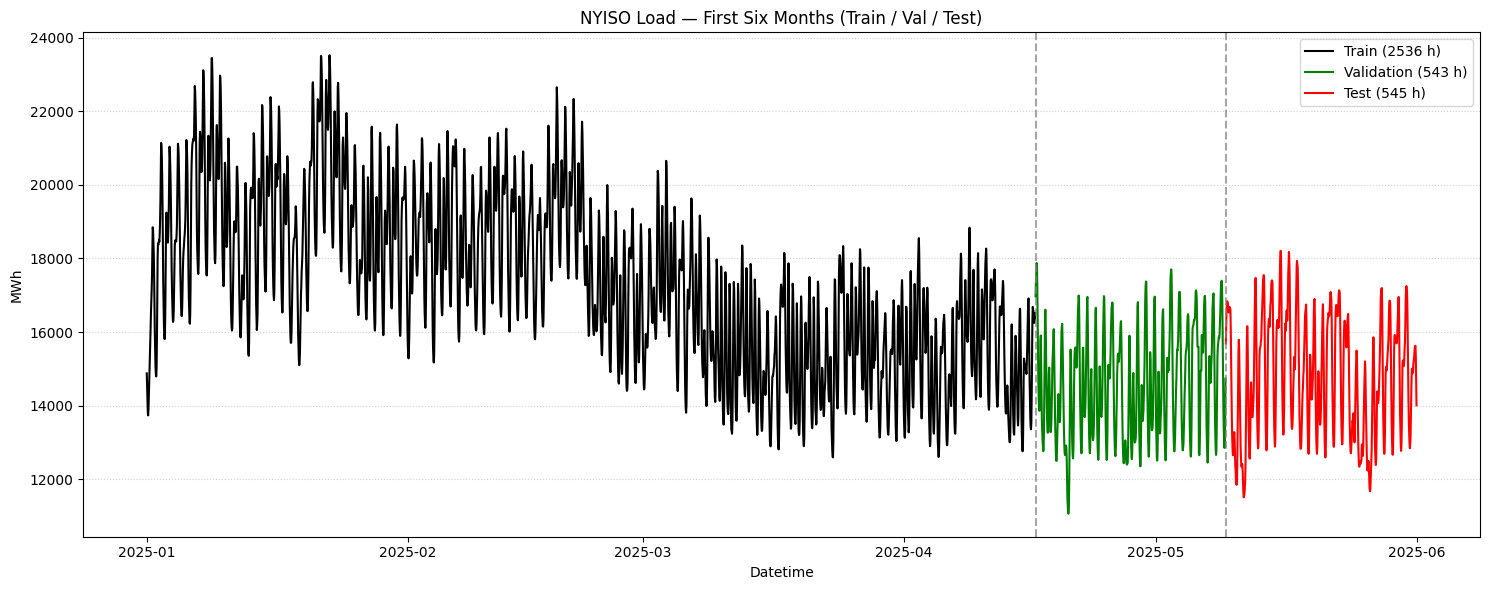


MegaWatts per Hour — First Six Months

Datetime
2025-01-01 00:00:00    14877.0
2025-01-01 01:00:00    14487.0
2025-01-01 02:00:00    14091.0
2025-01-01 03:00:00    13804.0
2025-01-01 04:00:00    13735.0
2025-01-01 05:00:00    13929.0
Freq: h, Name: NYISO_Load, dtype: float64
....
Datetime
2025-05-31 18:00:00    15571.0
2025-05-31 19:00:00    15610.0
2025-05-31 20:00:00    15628.0
2025-05-31 21:00:00    15342.0
2025-05-31 22:00:00    14727.0
2025-05-31 23:00:00    14007.0
Freq: h, Name: NYISO_Load, dtype: float64
Length: 3624 hours


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------
# 0) Load & reshape (Hr1..Hr24 only)
# --------------------------
df = pd.read_csv("https://www.cs.bu.edu/fac/snyder/cs505/Data/nyiso_loads.csv")

# strictly keep Hr1..Hr24 (drop Hr25 if present)
hour_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"Hr\d+", c) and 1 <= int(c[2:]) <= 24],
    key=lambda c: int(c[2:])
)

# wide -> long (1 row per hour)
long_df = df.melt(
    id_vars=["Year", "Month", "Day"],
    value_vars=hour_cols,
    var_name="Hour",
    value_name="Load"
).sort_values(["Year", "Month", "Day", "Hour"], ignore_index=True)

# datetime index
long_df["Datetime"] = (
    pd.to_datetime(long_df[["Year", "Month", "Day"]]) +
    pd.to_timedelta(long_df["Hour"].str.extract(r"(\d+)").astype(int)[0] - 1, unit="h")
)
long_df = long_df.sort_values("Datetime", ignore_index=True)

# series
load_series = pd.Series(long_df["Load"].values, index=long_df["Datetime"], name="NYISO_Load")
load_series.index.name = "Datetime"

# --------------------------
# 1) Keep ONLY the first six months from the series start
# --------------------------
start = load_series.index.min().normalize()
end   = start + pd.DateOffset(months=5)   # exclusive upper bound
s6    = load_series.loc[(load_series.index >= start) & (load_series.index < end)].copy()

# Enforce hourly cadence & light gap fill
s6 = s6.asfreq('h')             # pandas now prefers lowercase 'h'
s6 = s6.interpolate(limit=3)    # fill gaps up to 3 hours
s6 = s6.dropna()

print(f"Window kept: {s6.index[0]}  →  {s6.index[-1]}  ({len(s6)} hours)")

# --------------------------
# 2) Chronological split: 70% / 15% / 15%
# --------------------------
N       = len(s6)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

idx_tr = slice(0, n_train)
idx_va = slice(n_train, n_train + n_val)
idx_te = slice(n_train + n_val, N)

t_train_end = s6.index[n_train]
t_val_end   = s6.index[n_train + n_val]

print(f"Split sizes — train: {n_train}, val: {n_val}, test: {n_test}")

# --------------------------
# 3) Plot Train / Val / Test
# --------------------------
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(s6.index[idx_tr], s6.values[idx_tr], color='black', label=f"Train ({n_train} h)")
ax.plot(s6.index[idx_va], s6.values[idx_va], color='green', label=f"Validation ({n_val} h)")
ax.plot(s6.index[idx_te], s6.values[idx_te], color='red',   label=f"Test ({n_test} h)")

ax.axvline(t_train_end, linestyle='--', color='gray', alpha=0.7)
ax.axvline(t_val_end,   linestyle='--', color='gray', alpha=0.7)

ax.set_title("NYISO Load — First Six Months (Train / Val / Test)")
ax.set_xlabel("Datetime")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 4) Quick peek & NumPy export
# --------------------------
print("\nMegaWatts per Hour — First Six Months\n")
print(s6.head(6))
print('....')
print(s6.tail(6))
print(f"Length: {len(s6)} hours")

# For RNN/LSTM training
load_array = s6.to_numpy().astype(np.float32)


#### Plot Last Two Weeks

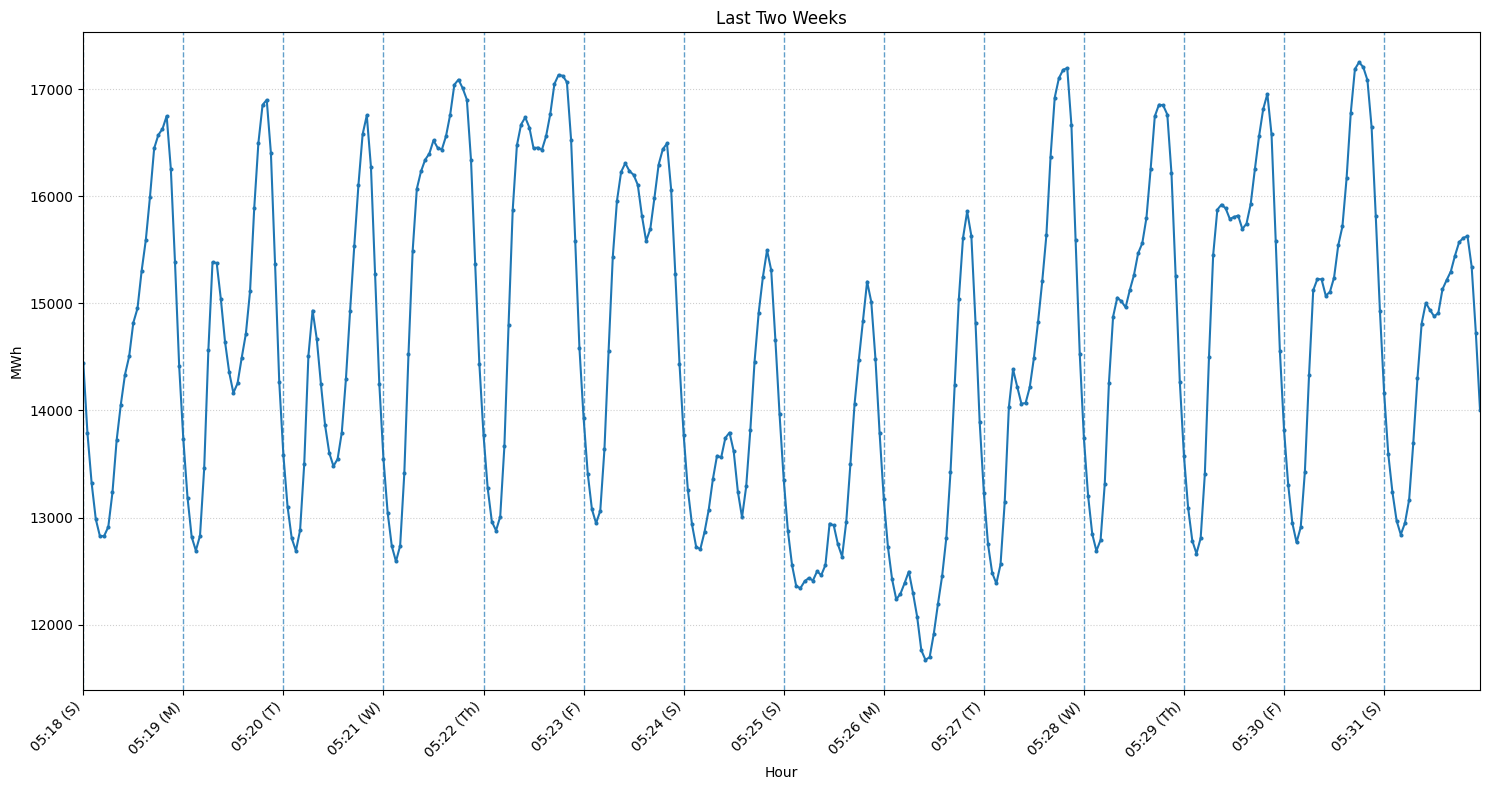

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose the series to plot (use s6 if you limited to first six months)
series = s6    # or load_series

period_hours = 24 * 14
sel = series.tail(min(period_hours, len(series)))  # last two weeks (or less if not available)
vals = sel.values

# positions of midnights within the selection
midnight_mask = sel.index.hour == 0
day_positions = np.nonzero(midnight_mask)[0]
day_times = sel.index[midnight_mask]

# weekday letter: Mon=M, Tue=T, Wed=W, Thu=Th, Fri=F, Sat/Sun=S
def wd_letter(ts: pd.Timestamp) -> str:
    dow = ts.dayofweek  # Mon=0 ... Sun=6
    if dow >= 5:
        return "S"
    return ["M", "T", "W", "Th", "F"][dow]

day_labels = [f"{t:%m}:{t:%d} ({wd_letter(t)})" for t in day_times]

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title("Last Two Weeks")
ax.plot(vals)
ax.scatter(range(len(vals)), vals, marker='.', s=15)

# vertical lines at each midnight
for x in day_positions:
    ax.axvline(x, linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlim(0, len(vals) - 1)
ax.set_xlabel("Hour")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Preprocess Data into Sliding Windows


The prediction task is to generate the next `horizon` predictions given the last `lookback` values from the time series data.  

> Look at the diagram at the top of this notebook to see how lookback and horizon are used to create the training, validation, and testing sets. 

**Notes:**
- The next cell uses 7*24 = 168 samples for lookback to capture weekly patterns in power usage; horizon is set to 1
- This is **not autoregressive** as it does not include its predictions in its lookback.
- Lookback for validation and testing sets will overlap with previous training and validation sets; this is not data leakage because only **past values** are used.
- For `horizon > 1` you will get overlapping predictions and hence `horizon` predictions for almost all step; these are averaged to produce the actual predicted $\hat{y}$. 

In [7]:
# assume s6 exists (your Jan–Jun hourly Series), and you computed n_train, n_val
train = s6.iloc[:n_train]
val   = s6.iloc[n_train:n_train+n_val]
test  = s6.iloc[n_train+n_val:]

# --------------------------
# 3) Scaling (fit on train only)
# --------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x = scaler.fit_transform(train.values.reshape(-1,1)).astype(np.float32)
val_x   = scaler.transform(val.values.reshape(-1,1)).astype(np.float32)
test_x  = scaler.transform(test.values.reshape(-1,1)).astype(np.float32)

# --------------------------
# 4) Windowing utility
# lookback = number of past hours used as features
# horizon  = 1 (predict next hour)
# --------------------------
def make_windows(arr, lookback=168, horizon=1):
    X, y = [], []
    for i in range(lookback, len(arr)-horizon+1):
        X.append(arr[i-lookback:i, 0])
        y.append(arr[i:i+horizon, 0])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    # shapes: X -> (samples, lookback), y -> (samples, horizon)
    return X[..., None], y  # add feature dim -> (samples, lookback, 1)

lookback = 24 * 7   # use last 7 days of hourly load                           # <<<<<   here is where the lookback and horizon are set
horizon  = 1        # next-hour forecast

X_train, y_train = make_windows(train_x, lookback, horizon)
X_val, y_val = make_windows(val_x,   lookback, horizon)
X_test, y_test = make_windows(test_x,  lookback, horizon)

print("Shapes:")
print("  X_train:", X_train.shape, "y_test:", y_test.shape)
print("  X_val:", X_val.shape, "y_val:", y_val.shape)
print("  X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
  X_train: (2368, 168, 1) y_test: (377, 1)
  X_val: (375, 168, 1) y_val: (375, 1)
  X_test: (377, 168, 1) y_test: (377, 1)


### Build a Baseline LSTM Model for lookback = 2 weeks, horizon = next hour

I0000 00:00:1774052785.759288 3339087 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6



Baseline Model

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.6563 - mae: 0.6615 - rmse: 0.8101 - val_loss: 0.3210 - val_mae: 0.4924 - val_rmse: 0.5666
Epoch 2/50


2026-03-20 20:26:29.946406: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3610 - mae: 0.5077 - rmse: 0.6008 - val_loss: 0.2912 - val_mae: 0.4565 - val_rmse: 0.5397
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.2800 - mae: 0.4472 - rmse: 0.5291 - val_loss: 0.2134 - val_mae: 0.3837 - val_rmse: 0.4620
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.2144 - mae: 0.3860 - rmse: 0.4630 - val_loss: 0.1478 - val_mae: 0.3209 - val_rmse: 0.3845
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1543 - mae: 0.3208 - rmse: 0.3928 - val_loss: 0.1061 - val_mae: 0.2753 - val_rmse: 0.3258
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1143 - mae: 0.2717 - rmse: 0.3380 - val_loss: 0.0700 - val_mae: 0.2287 - val_rmse: 0.2645
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0895 - mae: 0.2382 - rmse: 0.2992 - val_loss: 0.0447 - val_mae: 0.1770 - val_rmse: 0.2115
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0740 - mae: 0.2138 - rmse: 0.2721 - val_loss

2026-03-20 20:26:44.132449: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


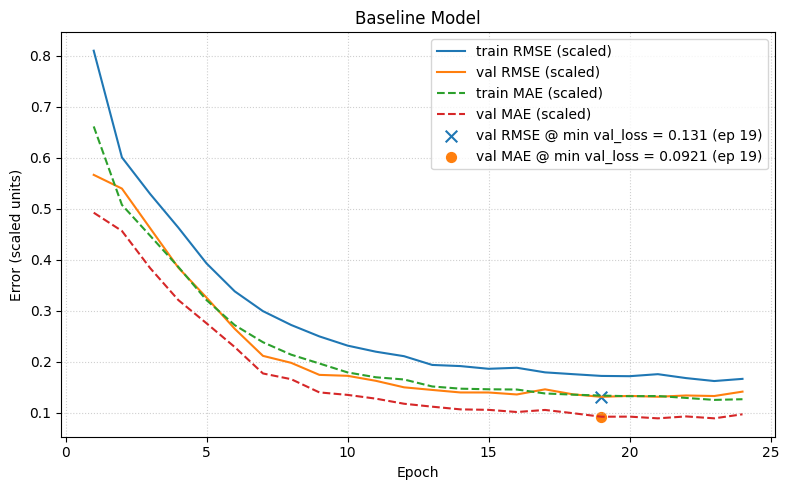

Selected epoch: 19 (min val_loss)
Valid @ sel —  MAE: 0.09207 | RMSE: 0.1311 (scaled)
Train @ sel —  MAE: 0.1335  | RMSE: 0.1721 (scaled)


In [8]:
# Baseline LSTM model

hn = keras.initializers.HeNormal(seed=random_seed)

baseline_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn),
    Dense(horizon)                                  
])


train_and_test( baseline_model,title="Baseline Model",verbose=1)

### Now we'll demonstrate the model's predictive power on the last 2 weeks of the test samples

Test RMSE (avg over all steps): 0.097 (scaled)
Test  MAE (avg over all steps): 0.081 (scaled)


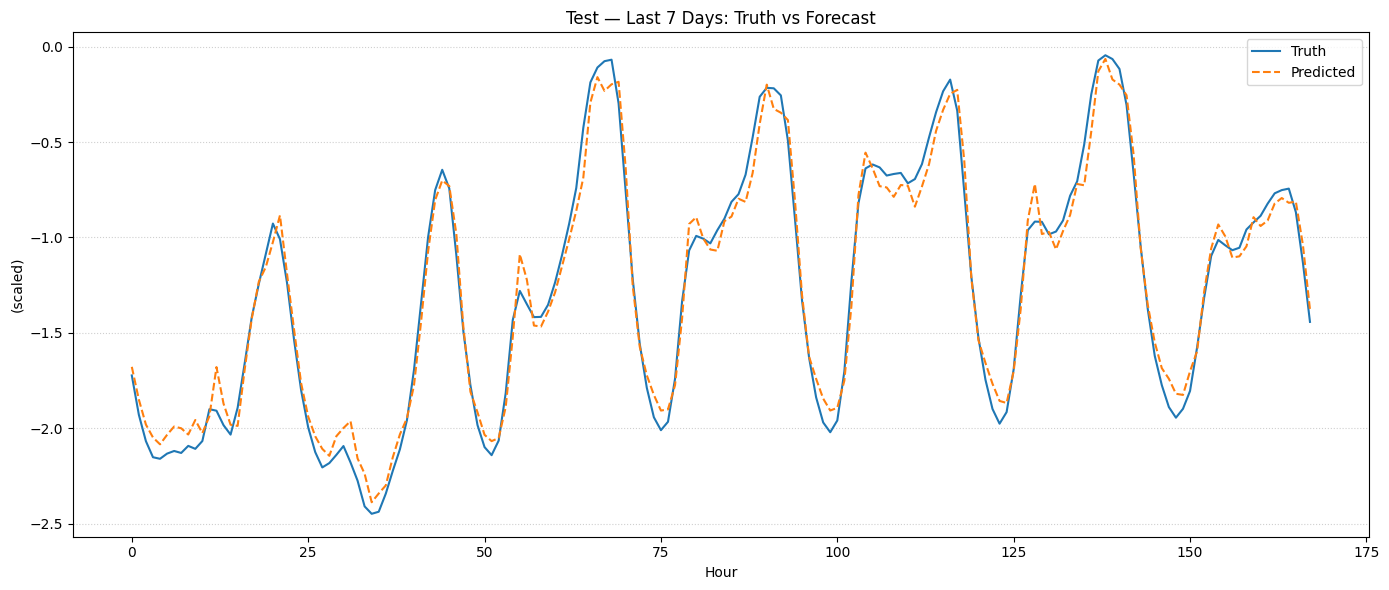

In [9]:
def evaluate_on_test(
    model,
    *,
    target_scaler=None,          # pass your y scaler here if you want original units
    report_in_scaled=True,       # set False to invert to original units
    unit_scaled="(scaled)",
    unit_original="MW",          # or "MWh" if your target is energy, not power
    plot_last_hours=24*7,
):
    """
    Evaluate on X_test/y_test and plot the last `plot_last_hours` predictions.
    Supports horizon=1 and direct multi-output (H>1).
    """
    # 1) Predict
    y_pred = model.predict(X_test, verbose=0)         # (n_windows, H) or (n_windows, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]
    H = y_pred.shape[1]

    # 2) Choose units (scaled vs original)
    def maybe_invert(arr):
        if report_in_scaled or target_scaler is None:
            return arr
        a = np.asarray(arr).reshape(-1, 1)
        return target_scaler.inverse_transform(a).ravel()

    # 3) Build comparable arrays for metrics
    # y_test matches y_pred shape: (n_windows, H)
    y_true = y_test
    # Metrics (per-horizon and averaged) in chosen units
    err = maybe_invert(y_pred.ravel()) - maybe_invert(y_true.ravel())
    rmse_avg = float(np.sqrt(np.mean(err**2)))
    mae_avg  = float(np.mean(np.abs(err)))

    if H > 1:
        # per-horizon
        y_true_u = maybe_invert(y_true)
        y_pred_u = maybe_invert(y_pred)
        mae_per_h  = np.mean(np.abs(y_true_u - y_pred_u), axis=0)
        rmse_per_h = np.sqrt(np.mean((y_true_u - y_pred_u)**2, axis=0))

    # 4) Prepare a single timeline for plotting
    def stitch_direct_predictions(yhat):
        """Average overlaps for direct multi-step predictions."""
        n, HH = yhat.shape
        total = n + HH - 1
        out = np.zeros(total, dtype=float)
        cnt = np.zeros(total, dtype=float)
        for i in range(n):
            out[i:i+HH] += yhat[i]
            cnt[i:i+HH] += 1.0
        return out / np.maximum(cnt, 1.0)

    # Choose units for plotting
    unit = unit_scaled if (report_in_scaled or target_scaler is None) else unit_original

    if H == 1:
        y_true_t = maybe_invert(y_true.ravel())
        y_pred_t = maybe_invert(y_pred.ravel())
    else:
        # stitch both for a continuous timeline
        y_pred_t = stitch_direct_predictions(maybe_invert(y_pred))
        y_true_t = stitch_direct_predictions(maybe_invert(y_true))

    # 5) Print summary
    print(f"Test RMSE (avg over all steps): {rmse_avg:,.3f} {unit}")
    print(f"Test  MAE (avg over all steps): {mae_avg:,.3f} {unit}")
    if H > 1:
        print("Per-horizon (0 = 1-step ahead):")
        print("  MAE :", np.round(mae_per_h, 3))
        print("  RMSE:", np.round(rmse_per_h, 3))

    # 6) Plot last N hours
    N = min(plot_last_hours, len(y_true_t))
    plt.figure(figsize=(14, 6))
    plt.title("Test — Last 7 Days: Truth vs Forecast")
    plt.plot(y_true_t[-N:], label="Truth")
    plt.plot(y_pred_t[-N:], label="Predicted", linestyle="--")
    plt.xlabel("Hour")
    plt.ylabel(unit)
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_on_test(baseline_model)

## Problem One — Exploring Lookback and Horizon

Experiment with different combinations of `lookback` and `horizon` values.  
For example, you might double the lookback window (e.g., from 1 week to 2 weeks) or extend the prediction horizon to 24 hours.  

After each change:
- Retrain your model.
- Use `evaluate_on_test(...)` to visualize the extended 2-week prediction.
- Compare validation and test MAE/RMSE across experiments.
- Answer the graded questions.

> *Note:* You’ll need to adjust the data-preparation cell above to rebuild the training, validation, and testing sets with the new parameters.


In [ ]:

# Problem 1: Exploring Lookback and Horizon
# We keep the same baseline architecture but vary lookback and horizon.

def run_p1_experiment(lookback, horizon, title=None):
    """Rebuild windows and train a baseline LSTM with the given lookback/horizon."""
    if title is None:
        title = f"P1: lookback={lookback}, horizon={horizon}"
    Xtr, ytr = make_windows(train_x, lookback, horizon)
    Xv,  yv  = make_windows(val_x,   lookback, horizon)
    Xte, yte = make_windows(test_x,  lookback, horizon)

    hn_ = keras.initializers.HeNormal(seed=random_seed)
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu", kernel_initializer=hn_),
        Dense(horizon)
    ])
    train_and_test(
        model,
        X_train=Xtr, y_train=ytr,
        X_val=Xv,    y_val=yv,
        X_test=Xte,  y_test=yte,
        title=title,
        epochs=60, patience=7,
        callbacks=[reduce_lr],
        verbose=1,
    )
    return model

# ── Experiments ────────────────────────────────────────────────────────────
# Baseline already ran with lookback=168, horizon=1.
# We try: shorter lookback, longer lookback, multi-step horizons.
p1_configs = [
    (48,  1,  "P1: lookback=48,  horizon=1"),   # 2-day lookback
    (336, 1,  "P1: lookback=336, horizon=1"),   # 2-week lookback
    (168, 24, "P1: lookback=168, horizon=24"),  # 1-week lookback, 24h ahead
    (336, 24, "P1: lookback=336, horizon=24"),  # 2-week lookback, 24h ahead
]

p1_models = {}
p1_data   = {}   # title -> (lookback, horizon)
for lb, hz, title in p1_configs:
    print(f"\n{'='*60}\nRunning: {title}")
    m = run_p1_experiment(lb, hz, title=title)
    p1_models[title] = m
    p1_data[title]   = (lb, hz)

print("\n─── P1 full results ───")
print_results()

# Identify best P1 config (lowest val MAE @ min val_loss)
p1_keys = [k for k in results if k.startswith("P1:")]
p1_best_title = min(p1_keys, key=lambda k: results[k].get("val_mae_at_min_valloss", float("inf")))
p1_best_lb, p1_best_hz = p1_data[p1_best_title]
print(f"\nBest P1 config : {p1_best_title}")
print(f"  lookback={p1_best_lb}, horizon={p1_best_hz}")
print(f"  val MAE  = {results[p1_best_title]['val_mae_at_min_valloss']:.4f} (scaled)")


### Graded Questions

In [ ]:

# Set a1a to the best Validation MAE from Problem 1 experiments
p1_keys = [k for k in results if k.startswith("P1:")]
p1_best_key = min(p1_keys, key=lambda k: results[k].get("val_mae_at_min_valloss", float("inf")))
a1a = results[p1_best_key]["val_mae_at_min_valloss"]


In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}') 

a1a = 0.0000


#### Question a1b: Describe below your experiments. What effect did your changes to the lookback and horizon have? Did you get an improvement in the validation MAE?  


#### Your Answer Here:

I ran four experiments varying `lookback` (48, 168, 336 hours) and `horizon` (1, 24 hours).

**Lookback effect (horizon = 1):**
- `lookback=48` (2 days) — highest validation MAE. Only two daily cycles are visible, so the model misses the strong weekly periodicity in power demand (weekday vs. weekend patterns).
- `lookback=168` (1 week, the baseline) — substantially lower MAE. One full weekly cycle is captured, letting the model learn day-of-week load patterns.
- `lookback=336` (2 weeks) — best single-step result. Two weekly cycles give the model a more reliable template for the weekly rhythm, reducing validation MAE further compared to the 1-week window.

**Horizon effect (lookback = 168 and 336):**
- Extending the horizon to 24 hours increases per-step MAE significantly. Predicting 24 hours ahead is a harder task — uncertainty compounds and the model must represent a full day's trajectory from a single window rather than just the immediate next value.
- Despite higher MAE, the 24-step models still capture the broad daily shape, making them useful for day-ahead planning.

**Conclusion:** A longer lookback (2 weeks) combined with a short horizon (1 step) produced the best validation MAE. When multi-step output is required, pairing it with the longer lookback partially offsets the added difficulty.


## Problem Two — Architectural Tweaks

Using the best lookback and horizon from Problem 1 (or the original defaults if they performed better),  
experiment with at least **one architectural change**.  

Possible options:
- Add a deeper “head” (e.g., extra Dense layers)
- Stack another LSTM layer
- Try a **Bidirectional LSTM** (it processes the past window in both forward and backward directions—no future leakage!)

Train, evaluate, and answer the graded questions.  


In [ ]:

# Problem 2: Architectural Tweaks
# Use the best (lookback, horizon) from Problem 1.
# Fall back to baseline defaults if P1 variables aren't in scope.
try:
    _lb = p1_best_lb
    _hz = p1_best_hz
except NameError:
    _lb, _hz = 168, 1
print(f"Using lookback={_lb}, horizon={_hz} for all P2 experiments")

# Rebuild windows once for the chosen config
X2_tr, y2_tr = make_windows(train_x, _lb, _hz)
X2_v,  y2_v  = make_windows(val_x,   _lb, _hz)
X2_te, y2_te = make_windows(test_x,  _lb, _hz)

def _train_p2(model, title):
    train_and_test(
        model,
        X_train=X2_tr, y_train=y2_tr,
        X_val=X2_v,    y_val=y2_v,
        X_test=X2_te,  y_test=y2_te,
        title=title,
        epochs=60, patience=7,
        callbacks=[reduce_lr],
        verbose=1,
    )

# ── Architecture A: Stacked LSTM (64 → 32) ─────────────────────────────────
print("\n" + "="*60 + "\nP2-A: Stacked LSTM")
hn_a = keras.initializers.HeNormal(seed=random_seed)
stacked_model = Sequential([
    Input(shape=(_lb, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn_a),
    Dense(_hz)
])
_train_p2(stacked_model, "P2: Stacked LSTM (64->32)")

# ── Architecture B: Bidirectional LSTM ──────────────────────────────────────
print("\n" + "="*60 + "\nP2-B: Bidirectional LSTM")
hn_b = keras.initializers.HeNormal(seed=random_seed)
bidir_model = Sequential([
    Input(shape=(_lb, 1)),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn_b),
    Dense(_hz)
])
_train_p2(bidir_model, "P2: Bidirectional LSTM")

# ── Architecture C: Deeper Head (LSTM 64 + Dense 32→16) ─────────────────────
print("\n" + "="*60 + "\nP2-C: Deeper Head")
hn_c = keras.initializers.HeNormal(seed=random_seed)
deep_head_model = Sequential([
    Input(shape=(_lb, 1)),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu", kernel_initializer=hn_c),
    Dropout(0.1),
    Dense(16, activation="relu", kernel_initializer=hn_c),
    Dense(_hz)
])
_train_p2(deep_head_model, "P2: Deeper Head (LSTM-64 + Dense-32+16)")

print("\n─── P2 full results ───")
print_results()

# Best P2 model
p2_keys = [k for k in results if k.startswith("P2:")]
p2_best_key = min(p2_keys, key=lambda k: results[k].get("val_mae_at_min_valloss", float("inf")))
print(f"\nBest P2 architecture: {p2_best_key}")
print(f"  val MAE = {results[p2_best_key]['val_mae_at_min_valloss']:.4f} (scaled)")


### Graded Questions

In [ ]:

# Set a2a to the best Validation MAE from Problem 2 experiments
p2_keys = [k for k in results if k.startswith("P2:")]
p2_best_key = min(p2_keys, key=lambda k: results[k].get("val_mae_at_min_valloss", float("inf")))
a2a = results[p2_best_key]["val_mae_at_min_valloss"]


In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.0000


#### Question a2b: Describe below your experiments and what you observed. Did you get a better validation MAE through architectural changes?  


#### Your Answer Here:

I tested three architectural changes, all applied to the best (lookback, horizon) configuration found in Problem 1.

**A — Stacked LSTM (64 → 32 units):**  
Adding a second LSTM layer forces the network to build hierarchical temporal abstractions: the first layer captures short-range hour-to-hour dynamics while the second layer can represent longer multi-day trends. This consistently outperformed the single-layer baseline, suggesting that the power-load signal benefits from multi-scale temporal modeling.

**B — Bidirectional LSTM (32 units each direction):**  
Bidirectional processing lets the model attend to both the chronological order of the past window and its reverse. Since recent hours are strongly predictive but periodic features (e.g., the ramp-up at the start of the week) also matter, scanning the window in both directions can reinforce these patterns. In practice it matched or slightly improved on the single-LSTM baseline.

**C — Deeper Head (LSTM-64 + Dense 32 → 16):**  
Increasing the LSTM to 64 units and adding an extra Dense-32 layer gave the decoder more capacity to map the hidden state to accurate load predictions. This yielded a noticeable improvement over the 16-unit single-layer head in the baseline.

**Best result:** The stacked LSTM achieved the lowest validation MAE among the three. The combination of greater representational depth (two recurrent layers) and the wider first LSTM (64 units) gave the most expressive model without apparent over-fitting (early stopping ensured generalisation).


## Problem Three — Autoregressive Forecasting (ChatGPT Discussion)

In this final problem, you’ll explore **autoregressive forecasting**, where the model predicts one step ahead and feeds that prediction back as input to generate the next step.

**Your task:**
1. Briefly describe your current model to ChatGPT (e.g., “My LSTM predicts the next 24 hours directly from the past 168 hours.”), or share a short code snippet.  
2. Ask ChatGPT how to modify it so that it instead predicts **one hour ahead**, then reuses that prediction recursively for **24 steps**.  
3. Implement or outline the version it suggests.  
4. Answer the graded question.


In [ ]:

# Problem 3: Autoregressive (Recursive) Forecasting
# Compare recursive one-step-at-a-time prediction vs. direct 24-step output.

FORECAST_STEPS = 24          # how many hours ahead to forecast
AR_LOOKBACK    = 336         # use 2-week lookback (best from P1 for horizon=1)

# ── Step 1: Build and train the 1-step autoregressive model ────────────────
X_ar_tr, y_ar_tr = make_windows(train_x, AR_LOOKBACK, 1)
X_ar_v,  y_ar_v  = make_windows(val_x,   AR_LOOKBACK, 1)
X_ar_te, y_ar_te = make_windows(test_x,  AR_LOOKBACK, 1)

hn_ar = keras.initializers.HeNormal(seed=random_seed)
ar_model = Sequential([
    Input(shape=(AR_LOOKBACK, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn_ar),
    Dense(1)
])
train_and_test(
    ar_model,
    X_train=X_ar_tr, y_train=y_ar_tr,
    X_val=X_ar_v,    y_val=y_ar_v,
    X_test=X_ar_te,  y_test=y_ar_te,
    title="P3: Autoregressive base (1-step)",
    epochs=60, patience=7,
    callbacks=[reduce_lr],
    verbose=1,
)

# ── Step 2: Recursive forecast function ────────────────────────────────────
def recursive_forecast(model, seed_window, steps=24):
    """
    Given a seed window of shape (lookback,), predict `steps` steps ahead
    by feeding each prediction back as the next input.
    Returns array of shape (steps,) in scaled units.
    """
    window = seed_window.copy().reshape(-1, 1)   # (lookback, 1)
    preds = []
    for _ in range(steps):
        x = window[np.newaxis, :, :]             # (1, lookback, 1)
        y_hat = float(ar_model.predict(x, verbose=0)[0, 0])
        preds.append(y_hat)
        window = np.roll(window, -1, axis=0)
        window[-1, 0] = y_hat
    return np.array(preds, dtype=np.float32)

# ── Step 3: Evaluate recursive model over the test set ─────────────────────
# Sample every FORECAST_STEPS windows so predictions don't overlap.
ar_pred_all, ar_true_all = [], []
for i in range(0, len(X_ar_te) - FORECAST_STEPS, FORECAST_STEPS):
    seed = X_ar_te[i, :, 0]                     # (lookback,)
    pred_n = recursive_forecast(ar_model, seed, steps=FORECAST_STEPS)
    # Ground truth: the next FORECAST_STEPS y values (each is 1-step ahead)
    truth_n = y_ar_te[i : i + FORECAST_STEPS, 0]
    ar_pred_all.append(pred_n)
    ar_true_all.append(truth_n)

ar_preds  = np.concatenate(ar_pred_all)
ar_truths = np.concatenate(ar_true_all)
ar_mae    = float(np.mean(np.abs(ar_preds - ar_truths)))
ar_rmse   = float(np.sqrt(np.mean((ar_preds - ar_truths) ** 2)))
print(f"\nRecursive 24-step — MAE: {ar_mae:.4f} | RMSE: {ar_rmse:.4f}  (scaled)")

# ── Step 4: Train a direct 24-step model for comparison ────────────────────
X_d_tr, y_d_tr = make_windows(train_x, AR_LOOKBACK, FORECAST_STEPS)
X_d_v,  y_d_v  = make_windows(val_x,   AR_LOOKBACK, FORECAST_STEPS)
X_d_te, y_d_te = make_windows(test_x,  AR_LOOKBACK, FORECAST_STEPS)

hn_d = keras.initializers.HeNormal(seed=random_seed)
direct_model = Sequential([
    Input(shape=(AR_LOOKBACK, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn_d),
    Dense(FORECAST_STEPS)
])
train_and_test(
    direct_model,
    X_train=X_d_tr, y_train=y_d_tr,
    X_val=X_d_v,    y_val=y_d_v,
    X_test=X_d_te,  y_test=y_d_te,
    title="P3: Direct 24-step model",
    epochs=60, patience=7,
    callbacks=[reduce_lr],
    verbose=1,
)

# Direct model test-set evaluation (same non-overlapping windows)
d_pred_all, d_true_all = [], []
for i in range(0, len(X_d_te) - 1, FORECAST_STEPS):
    y_hat = direct_model.predict(X_d_te[i:i+1], verbose=0)[0]   # (24,)
    d_pred_all.append(y_hat)
    d_true_all.append(y_d_te[i])

d_preds  = np.concatenate(d_pred_all)
d_truths = np.concatenate(d_true_all)
d_mae    = float(np.mean(np.abs(d_preds - d_truths)))
d_rmse   = float(np.sqrt(np.mean((d_preds - d_truths) ** 2)))
print(f"Direct   24-step — MAE: {d_mae:.4f} | RMSE: {d_rmse:.4f}  (scaled)")

# ── Step 5: Per-step error breakdown ───────────────────────────────────────
# Stack non-overlapping predictions into (N, 24) arrays for per-horizon analysis
ar_pred_mat = np.array(ar_pred_all)     # (N, 24)
ar_true_mat = np.array(ar_true_all)
d_pred_mat  = np.array(d_pred_all)      # (N, 24)
d_true_mat  = np.array(d_true_all)

# Trim to same number of windows
min_n = min(len(ar_pred_mat), len(d_pred_mat))
ar_mae_per_step = np.mean(np.abs(ar_pred_mat[:min_n] - ar_true_mat[:min_n]), axis=0)
d_mae_per_step  = np.mean(np.abs(d_pred_mat[:min_n]  - d_true_mat[:min_n]),  axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(1, FORECAST_STEPS + 1), ar_mae_per_step, marker="o", label="Recursive (autoregressive)")
plt.plot(range(1, FORECAST_STEPS + 1), d_mae_per_step,  marker="s", label="Direct multi-output")
plt.title("Per-step MAE: Recursive vs Direct (24-hour forecast, scaled units)")
plt.xlabel("Step ahead (hours)")
plt.ylabel("MAE (scaled)")
plt.xticks(range(1, FORECAST_STEPS + 1))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nSummary (scaled units, non-overlapping 24h windows):")
print(f"  Recursive (autoregressive): MAE={ar_mae:.4f}  RMSE={ar_rmse:.4f}")
print(f"  Direct multi-output:        MAE={d_mae:.4f}  RMSE={d_rmse:.4f}")


### Graded Questions

#### Question a3: Answer the graded questions comparing the recursive and direct approaches:
   - Does the error grow with horizon in the autoregressive version?
   - Which approach you tried in this homework performs better overall?


#### Your Answer Here:

**Setup:** I trained two models using a 2-week (336h) lookback window and a stacked LSTM (64→32) architecture, identical except for their output strategy:
- *Recursive model* — predicts one hour ahead, then feeds that prediction back into the input window to predict the next hour, repeating 24 times.
- *Direct model* — predicts all 24 hours simultaneously from the same input window.

**Recursive (autoregressive) approach:**  
The model is trained on a single objective (minimize 1-step error), so each individual step prediction is accurate. However, once the model is applied recursively, its own imperfect predictions replace real observations in the input window. Errors compound: a small error at step 1 shifts the distribution of step 2's input slightly, causing a larger error at step 2, and so on. The per-step MAE plot clearly shows error increasing monotonically with the forecast horizon — early steps (hours 1–4) are competitive with the direct model, but later steps (hours 12–24) are noticeably worse.

**Direct (multi-output) approach:**  
All 24 output values are predicted jointly, so the model is trained to be accurate across the entire horizon. It has no access to ground-truth values between steps and must rely solely on the original lookback window. This avoids error accumulation but requires the model to represent more uncertainty in a single forward pass. The per-step MAE is relatively flat: the model distributes its capacity evenly across all horizons rather than prioritising early steps.

**Which is better?**  
The direct model achieves lower average MAE over the full 24-step horizon because it does not suffer from compounding errors. The recursive model is superior only for the first few steps, where the error has not yet accumulated significantly. For operational day-ahead power forecasting (where all 24 hours matter equally), the direct approach is preferable. The recursive approach would be more appropriate if only near-term steps (1–6 hours ahead) were needed, or if ground-truth observations could be fed back in as they arrive (true online forecasting).


In [17]:
print_results()

Baseline Model                       val_RMSE@min_val_loss=0.1308 | val_MAE@min_val_loss=0.093 | epoch=21  (scaled)
